<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões e deformações na flexão pura

### Problema 4
Considere a viga ABCD ligada a um apoio simples em A e a um apoio móvel em C e suportando duas cargas concentradas $P = 6$ kN aplicadas nas secções B e D e uma carga distribuída $Q = 2$ kN/m aplicada entre A e B, como indicado na figura. A viga tem a secção transversal representada.

a) Trace os diagramas do esforço transverso e do momento fletor.

b) Determine as tensões normais máximas e mínimas para a secção mais solicitada e represente a variação da tensão normal nessa secção.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au01/P4/MSII_Au01_P4.png"
width="900" />

## Resolução

**a) Trace os diagramas do esforço transverso e do momento fletor.**

In [20]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

plt.rcParams['axes.facecolor'] = (.15, .15, .15)
plt.rcParams['figure.facecolor'] = (.15, .15, .15)
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 18
# plt.rcParams['text.usetex'] = True
params = {"ytick.color" : (.8, .8, .8),
          "xtick.color" : (.8, .8, .8),
          "grid.color" : (.2, .2, .2),
          "text.color" : (.7, .7, .7),
          "axes.labelcolor" : (.8, .8, .8),
          "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: SI: kN, m
class varin: pass
P4 = varin()  # Create an empty class

# units: N, m, Pa
P4.P = 6e3 # N
P4.Q = 2e3 # N/m
P4.AB = 1
P4.BC = 3
P4.CD = 1

Diagrama de esforços : cálculo das reações + método das secções

#### Diagrama de corpo livre

No DCL existem 3 reações:
- Apoio duplo: $R_{Ax}, R_{Ay}$
- Apoio simples: $R_{Cy}$

#### Equações de Equilíbrio

\begin{equation*}
\begin{cases}
\rightarrow(+)&:& \sum F_x = 0 \\
\uparrow(+) &:&\sum F_y = 0 \\
\circlearrowleft(+)&:& \sum M_C = 0
\end{cases}
~\Leftrightarrow~
\begin{cases}
R_{Ax} = 0 \\
R_{Ay} + R_{Cy} - Q_{r} - P_{B} - P_{D} = 0 \\
-R_{Ay}\cdot(L_{AC}) + Q_{r}\cdot\left(L_{AC}-\frac{L_{AB}}{2}\right) +
P_{B}\cdot L_{BC} - P_{D}\cdot L_{CD} = 0
\end{cases}
\end{equation*}

In [21]:
rax, ray, rcy = sy.symbols('rax ray rcy')

P4.AC = P4.AB + P4.BC

Qr = P4.Q*P4.AB
print(f'Q(res) = {Qr:.3f} N')

print('---------------------------------')
print('Equilíbrio - sistema de equações:')
print('---------------------------------')
sumFx = rax
print('Sum Fx :',sumFx)
sumFy = ray + rcy - Qr - 2*P4.P
print('Sum Fy :',sumFy)
sumMC = -ray*(P4.AC) + Qr*(P4.AC-P4.AB/2) + P4.P*P4.BC - P4.P*P4.CD
print('sumMC :',sumMC)

Q(res) = 2000.000 N
---------------------------------
Equilíbrio - sistema de equações:
---------------------------------
Sum Fx : rax
Sum Fy : ray + rcy - 14000.0
sumMC : 19000.0 - 4*ray


In [22]:
sol = solve({sumFx,sumFy, sumMC},{rax, ray, rcy})

print('---------')
print('Reações :')
print('---------')
RAx = sol[rax]; print(f'RBx = {RAx:.1f} kN')
RAy = sol[ray]; print(f'RBy = {RAy*1e-3:.2f} kN')
RCy = sol[rcy]; print(f'RDy = {RCy*1e-3:.2f} kN')

---------
Reações :
---------
RBx = 0.0 kN
RBy = 4.75 kN
RDy = 9.25 kN


#### Equações por troços do diagrama de esforços: método das secções

#### Troço AB

In [23]:
vab, mab, x = sy.symbols('vab mab x')

EQ_VAB = RAy - P4.Q*x - vab
EQ_MAB = -RAy*x + P4.Q*x*(x/2) + mab

sol = solve({EQ_VAB,EQ_MAB},{vab, mab})

print('\n---------')
print('Troço AB:')
print('---------')
VAB = sol[vab]; print(f'Esforço Transverso, V(x) = {VAB} kN')
MAB = sol[mab]; print(f'Momento fletor, M(x) = {MAB} kN.m')

print('\n --- Valores nos extremos do intervalo: --')
VAB_A = VAB.subs({(x,0)})
print(f'VAB(x=0) = {VAB_A*1e-3:.2f} kN')
MAB_A = MAB.subs({(x,0)})
print(f'MAB(x=0) = {MAB_A} kNm')
VAB_B = VAB.subs({(x,P4.AB)})
print(f'VAB(x=LAB) = {VAB_B*1e-3:.2f} kN')
MAB_B = MAB.subs({(x,P4.AB)})
print(f'MAB(x=LAB) = {MAB_B*1e-3:.2f} kN.m')


---------
Troço AB:
---------
Esforço Transverso, V(x) = 4750.0 - 2000.0*x kN
Momento fletor, M(x) = -1000.0*x**2 + 4750.0*x kN.m

 --- Valores nos extremos do intervalo: --
VAB(x=0) = 4.75 kN
MAB(x=0) = 0 kNm
VAB(x=LAB) = 2.75 kN
MAB(x=LAB) = 3.75 kN.m


#### Troço BC

In [24]:
vbc, mbc = sy.symbols('vbc mbc')

EQ_VBC = RAy - Qr - P4.P - vbc
EQ_MBC = -RAy*x + Qr*(x-P4.AB/2) + P4.P*(x-P4.AB) + mbc

sol = solve({EQ_VBC,EQ_MBC},{vbc, mbc})

print('\n---------')
print('Troço BC:')
print('---------')
VBC = sol[vbc]; print(f'Esforço Transverso, V(x) = {VBC:.2f} kN')
MBC = sol[mbc]; print(f'Momento fletor, M(x) = {MBC} kN.m')

print('\n --- Valores nos extremos do intervalo: --')
VBC_B = VBC.subs({(x,P4.AB)})
print(f'VBC(x=LAB) = {VBC_B*1e-3:.2f} kN')
MBC_B = MBC.subs({(x,P4.AB)})
print(f'MBC(x=LAB) = {MBC_B*1e-3:.2f} kNm')
print('\nc) ::::::::::::::::::::::::::::')
VBC_C = VBC.subs({(x,P4.AC)})
print(f'VBC(x=LAC) = {VBC_C*1e-3:.2f} kN')
MBC_C = MBC.subs({(x,P4.AC)})
print(f'MBC(x=LAC) = {MBC_C*1e-3:.2f} kNm')
print(':::::::::::::::::::::::::::::::')


---------
Troço BC:
---------
Esforço Transverso, V(x) = -3250.00 kN
Momento fletor, M(x) = 7000.0 - 3250.0*x kN.m

 --- Valores nos extremos do intervalo: --
VBC(x=LAB) = -3.25 kN
MBC(x=LAB) = 3.75 kNm

c) ::::::::::::::::::::::::::::
VBC(x=LAC) = -3.25 kN
MBC(x=LAC) = -6.00 kNm
:::::::::::::::::::::::::::::::


#### Troço CD

In [25]:
P4.AD = P4.AC + P4.CD
vcd, mcd = sy.symbols('vcd mcd')

EQ_VCD = RAy + RCy - Qr - P4.P - vcd
EQ_MCD = -RAy*x + Qr*(x-P4.AB/2) + P4.P*(x-P4.AB) -RCy*(x-P4.AC) + mcd

sol = solve({EQ_VCD,EQ_MCD},{vcd, mcd})

print('\n---------')
print('Troço CD:')
print('---------')
VCD = sol[vcd]; print(f'Esforço Transverso, V(x) = {VCD:.2f} kN')
MCD = sol[mcd]; print(f'Momento fletor, M(x) = {MCD} kN.m')

print('\n --- Valores nos extremos do intervalo: --')
VCD_C = VCD.subs({(x,P4.AC)})
print(f'VCD(x=LAC) = {VCD_C*1e-3:.2f} kN')
MCD_C = MCD.subs({(x,P4.AC)})
print(f'MCD(x=LAC) = {MBC_C*1e-3:.2f} kNm')
print('\nc) ::::::::::::::::::::::::::::')
VCD_D = VCD.subs({(x,P4.AD)})
print(f'VCD(x=LAD) = {VCD_D*1e-3:.2f} kN')
MCD_D = MCD.subs({(x,P4.AD)})
print(f'MCD(x=LAD) = {MCD_D*1e-3} kNm')
print(':::::::::::::::::::::::::::::::')


---------
Troço CD:
---------
Esforço Transverso, V(x) = 6000.00 kN
Momento fletor, M(x) = 6000.0*x - 30000.0 kN.m

 --- Valores nos extremos do intervalo: --
VCD(x=LAC) = 6.00 kN
MCD(x=LAC) = -6.00 kNm

c) ::::::::::::::::::::::::::::
VCD(x=LAD) = 6.00 kN
MCD(x=LAD) = 0 kNm
:::::::::::::::::::::::::::::::


In [26]:
xAB = np.linspace(0,P4.AB)
xBC = np.linspace(P4.AB,P4.AC)
xCD = np.linspace(P4.AC,P4.AD)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
yVAB = sy2array(VAB*1e-3,xAB) #
yMAB = sy2array(MAB*1e-3,xAB) #

# BC
yVBC = sy2array(VBC*1e-3,xBC) #
yMBC = sy2array(MBC*1e-3,xBC) #

# CD
yVCD = sy2array(VCD*1e-3,xCD) #
yMCD = sy2array(MCD*1e-3,xCD) #

#### Diagrama de Esforço Transverso

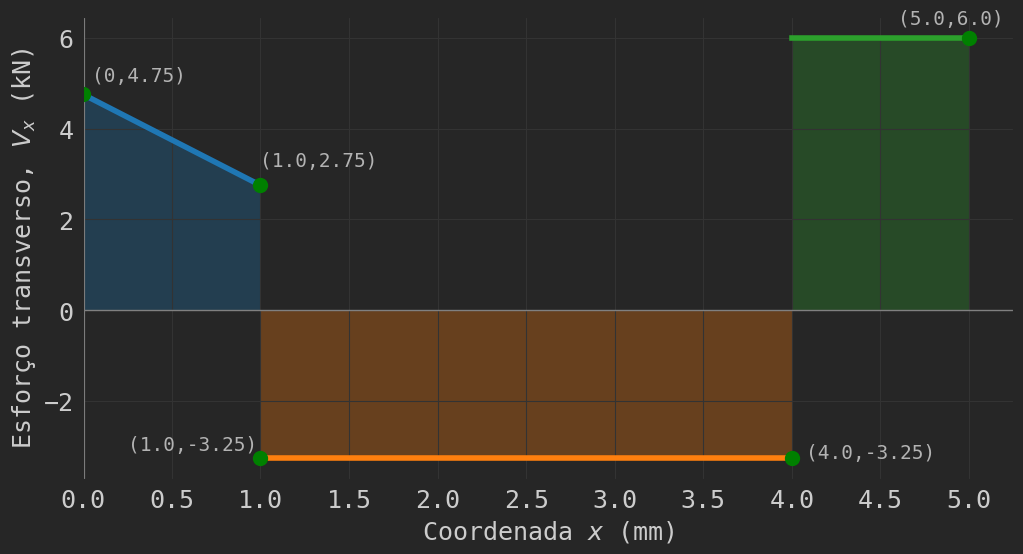

In [27]:
fz = 14

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yVAB,linewidth=4)
plt.fill_between(xAB,yVAB, alpha=.3)
plt.plot(xBC,yVBC,linewidth=4)
plt.fill_between(xBC,yVBC, alpha=.3)
plt.plot(xCD,yVCD,linewidth=4)
plt.fill_between(xCD,yVCD, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yVAB[0],'go',markersize=10)
plt.text(xAB[0]+.05,yVAB[0]+.3,f'({xAB[0]:.0f},{yVAB[0]:.2f})',fontsize=fz)
plt.plot(xAB[-1],yVAB[-1],'go',markersize=10)
plt.text(xAB[-1]*1.,yVAB[-1]*1.15,f'({xAB[-1]:.1f},{yVAB[-1]:.2f})',
         fontsize=fz)
plt.plot(xBC[0],yVBC[0],'go',markersize=10)
plt.text(xBC[0]*.25,yVBC[0]*.95,f'({xBC[0]:.1f},{yVBC[0]:.2f})',fontsize=fz)
plt.plot(xBC[-1],yVBC[-1],'go',markersize=10)
plt.text(xBC[-1]*1.02,yVBC[-1]*1.,f'({xBC[-1]:.1f},{yVBC[-1]:.2f})',
         fontsize=fz)
plt.plot(xCD[-1],yVCD[-1],'go',markersize=10)
plt.text(xCD[-1]*.92,yVCD[-1]*1.05,f'({xCD[-1]:.1f},{yVCD[-1]:.1f})',
         fontsize=fz)
plt.xlim(0,P4.AD*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, P4.AD*1.1, 0.5)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
# plt.ylim(-int(P4.p2*2),int(P4.p2*2))
plt.grid(True)
plt.show()

#### Diagrama de Momento Fletor

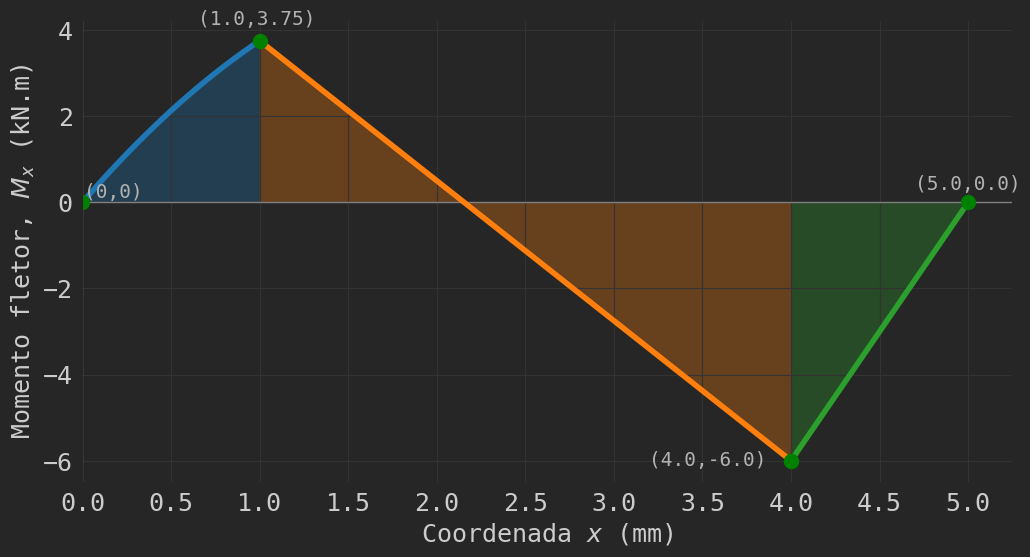

In [28]:
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yMAB,linewidth=4)
plt.fill_between(xAB,yMAB, alpha=.3)
plt.plot(xBC,yMBC,linewidth=4)
plt.fill_between(xBC,yMBC, alpha=.3)
plt.plot(xCD,yMCD,linewidth=4)
plt.fill_between(xCD,yMCD, alpha=.3)
plt.xlabel(r'Coordenada $x$ (mm)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],yMAB[0],'go',markersize=10)
plt.text(xAB[0]+.01,yMAB[0]+.1,f'({xAB[0]:.0f},{yMAB[0]:.0f})',fontsize=fz)
plt.plot(xBC[0],yMBC[0],'go',markersize=10)
plt.text(xBC[0]*.65,yMBC[0]*1.1,f'({xBC[0]:.1f},{yMBC[0]:.2f})',fontsize=fz)
plt.plot(xBC[-1],yMBC[-1],'go',markersize=10)
#plt.text(xBC[-1]*.75,yMBC[-1]-3.5,f'({xBC[-1]:.2f},{yMBC[-1]:.1f})',
# fontsize=fz)
plt.plot(xCD[0],yMCD[0],'go',markersize=10)
plt.text(xCD[0]*.8,yMCD[0]*1.02,f'({xCD[0]:.1f},{yMCD[0]:.1f})',fontsize=fz)
plt.plot(xCD[-1],yMCD[-1],'go',markersize=10)
plt.text(xCD[-1]*.94,yMCD[-1]+.3,f'({xCD[-1]:.1f},{yMCD[-1]:.1f})',fontsize=fz)
plt.xlim(0,P4.AD*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, P4.AD*1.1, 0.5)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

**b) Determine as tensões normais máximas e mínimas para a secção mais solicitada e represente a variação da tensão normal nessa secção.**

A geometria enunciada pode ser obtida recorrendo a operações booleanas tendo por base geometrias simples. A vantagem é que as propriedades geométricas de área para estas figuras simples  são conhecidas e fornecidas em tabelas. Neste caso a área de secção pode ser obtida somando um semi-círculo a um uma área rêctangular.

- Cálculo do centro geométrico da área composta

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au01/P4/MSII_Au01_P4_tab.png"
width="600" />

A área composta enunciada tem um plano de simetria. Desta forma a abscissa da  sua posição em relação a um sistema de coordenadas é bem determinado.  Contudo, a ordenada da posição do centróide não é conhecida _a priori_ e deve  ser calculada. Considere-se o origem do referêncial na base da área. O cálculo final do centróide será determinado com base no centróide das  figuras elementares que lhe dão origem:

\begin{equation*}
A\overline{y} = \sum_{i=1}^2 A_i \overline{y}_i
~\Leftrightarrow~
\overline{y} = \sum_{i=1}^2 \frac{A_i \overline{y}_i}{A_i} =
\frac{A_1 \overline{y}_1 + A_2 \overline{y}_2}{A_1 + A_2}
\end{equation*}

- Região 1 (área retangular) : Área, $A_1^\Box$

\begin{equation*}
A_1^\Box = l h
\end{equation*}

In [29]:
# Problem data
# units: N, mm, MPa
R1 = varin()
R1.l = 100 # unit: mm
R1.h = 50 # unit: ,m
R1.A = R1.l*R1.h
print(f'R1.A = {R1.A:.1f} mm²')

R1.A = 5000.0 mm²


- Região 1 (área retangular) : Centroide, $\overline{y}_1^\Box$

\begin{equation*}
\overline{y}_1^\Box = \frac{h}{2}
\end{equation*}

In [30]:
R1.yc = R1.h/2
print(f'R1.yc = {R1.yc:.1f} mm')

R1.yc = 25.0 mm


- Região 2 (área semi-círculo) : Área, $A_2$

\begin{equation*}
A_2 = \frac{\pi r^2}{2}
\end{equation*}

In [31]:
R2 = varin()
R2.r = 150 # unit: mm
# Half-circle area (region 2, R2)
R2.A = np.pi*R2.r**2/2
print(f'R2.A = {R2.A:.1f} mm²')

R2.A = 35342.9 mm²


- Região 2 (área semi-círculo) : Centroide, $\overline{y}_2$ (de tabelas)

\begin{equation*}
\overline{y}_2 = \frac{4 r}{3 \pi}
\end{equation*}

In [32]:
R2.yc = R1.h + 4*R2.r/3/np.pi
print(f'R2.yc = {R2.yc:.1f} mm')

R2.yc = 113.7 mm


Resultando,

|  - | $A_i$, mm $²$      |  $y_i$, mm | $A_iy_i$, mm $³$ |
|----------|:-------------:|:-------------:|------:|
| $\Box$ |  $l h$ |  $h/2$ | $lh^2/2$ |
| $\circ/$ | $\pi r^2/2$ |  $h  + 4 r/3 \pi$ | $(\pi r^2/2)(h  + 4 r/3 \pi)$ |
|  $\sum$ | $(l h)\pi r^2/2$ |  - | $(lh^2/2)(\pi r^2/2)(h  + 4 r/3 \pi)$ |

In [33]:
R1.Ayc = R1.A*R1.yc
print(f'R1.Ayc = {R1.Ayc:.1f} mm³')

R2.Ayc = R2.A*R2.yc
print(f'R2.Ayc = {R2.Ayc:.1f} mm³')

R = varin()
R.A = R1.A + R2.A
print(f'\nR.A = {R.A:.1f} mm²')
R.Ayc = R1.Ayc + R2.Ayc
print(f'R.Ayc = {R.Ayc:.1f} mm')

R.yc = (R1.A*R1.yc + R2.A*R2.yc)/R.A
print(f'------------------')
print(f'R.yc = {R.yc:.1f} mm')
print(f'------------------')

R1.Ayc = 125000.0 mm³
R2.Ayc = 4017145.9 mm³

R.A = 40342.9 mm²
R.Ayc = 4142145.9 mm
------------------
R.yc = 102.7 mm
------------------


- Cálculo do momento de inércia

\begin{equation*}
I = I_1^{\Box} + I_2^{\circ/}
\end{equation*}

- Região 1 (área retangular) : Momento de inércia, $I_1^\Box$

Recorrendo ao teorema dos eixos paralelos,

\begin{equation*}
I^\Box = I_{c}^\Box + A d_1² = \frac{bh^3}{13} + A_1^\Box \left(\overline{y} -
\frac{h}{2}\right)²
\end{equation*}

onde $d_1$ é a distância entre eixos paralelos e que passam, respetivamente, pelos centróide local da área retangular e o centróide global da área composta.

In [34]:
d1 = R.yc - R1.h/2
print(f'd1 = {d1:.1f} mm')

def mirect(b,h):
    return b*h**3/12

R1.I = mirect(R1.l,R1.h) + R1.A*d1**2
print(f'R1.I = {R1.I:.3e} mm⁴ = {R1.I*1e-12:.3e} m⁴')

d1 = 77.7 mm
R1.I = 3.121e+07 mm⁴ = 3.121e-05 m⁴


- Região 2 (área semi-círculo) : Momento de inércia, $I_1^\text{◓}$

Recorrendo ao teorema dos eixos paralelos,

\begin{equation*}
I^{\text{◓}} = I_{c}^{\text{◓}(1)}+ A d_2²
\qquad\wedge\qquad d_2 = \overline{y}_2 - \overline{y}
\end{equation*}

$d_2$ é a distância entre o centróide da área semi-circular e o centroide da área composta.

Da forma como as tabelas de consuta são apresentadas, contudo, é necessário um cálculo complementar do teorema dos eixos paralelos,

\begin{equation*}
I^{\text{◓}(2)} = I_{c}^{\text{◓}(1)} + A \overline{y}_3²
\qquad\textrm{- tabelas: -}\qquad
I^{\text{◓}(2)} = \frac{\pi r⁴}{8}
\quad\wedge\qquad \overline{y}_3 = \frac{4 r}{3 \pi}
\end{equation*}

de onde vem,

\begin{equation*}
I_{c}^{\text{◓}(1)} = I^{\text{◓}(2)} - A \overline{y}_3²
 = \frac{\pi r⁴}{8} - \frac{\pi r²}{2}\left(\frac{4 r}{3 \pi}\right)²
\end{equation*}

Finalmente,

\begin{equation*}
I^{\text{◓}} \equiv I_{c}^{\text{◓}(1)} = \left[ \frac{\pi r⁴}{8} - \frac{\pi r²}{2}\left(\frac{4 r}{3
\pi}\right)²\right] + \frac{\pi r²}{2}\left(\overline{y}_2 - \overline{y}\right)²
\end{equation*}

In [35]:
R2.I2 = np.pi*R2.r**4/8
print(f'R2.I2 = {R2.I2:.1f} mm⁴')
d3 = 4*R2.r/3/np.pi # R2.yc-R1.h
print(f'd3 = {d3:.2f} mm')
R2.I1 = R2.I2 - R2.A*d3**2
print(f'R2.I1 = {R2.I1:.1f} mm⁴')

d2 = R2.yc - R.yc
print(f'd2 = {d2:.2f} mm')

R2.I = R2.I1 + R2.A*d2**2
print(f'R2.I = {R2.I:.1f} mm⁴ = {R2.I:.3e} mm⁴')

R2.I2 = 198803910.1 mm⁴
d3 = 63.66 mm
R2.I1 = 55564461.3 mm⁴
d2 = 10.99 mm
R2.I = 59832050.7 mm⁴ = 5.983e+07 mm⁴


\begin{equation*}
I = I^{\Box} + I^{\circ/}
\end{equation*}

In [36]:
R.I = R1.I + R2.I
print(f'R.I = {R.I:.1f} mm⁴ = {R.I:.3e} mm⁴ = {R.I*1e-12:.3e} m⁴')

R.I = 91039529.2 mm⁴ = 9.104e+07 mm⁴ = 9.104e-05 m⁴


\begin{equation*}
\sigma_{xx} = -\frac{M_z}{I_z} y
\end{equation*}


ymax = 97.33 mm = 9.73e-02 m
Sig-xx-max = -6.41 (MPa)
ymax = -102.67 mm = -1.03e-01 m
Sig-xx-min = 6.77 (MPa)


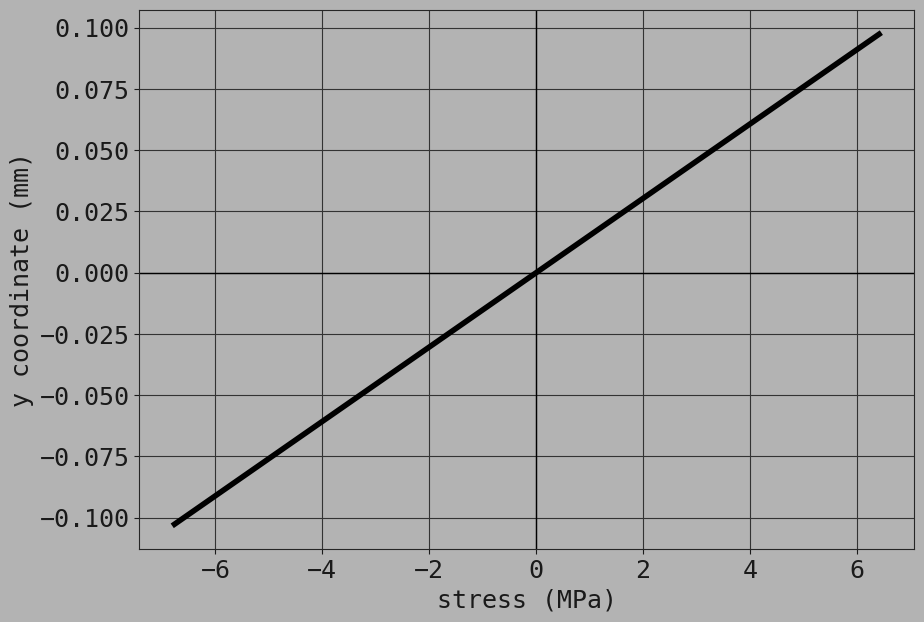

In [37]:
Isec = R.I*1e-12 # unit m^4
Mf = MBC_C # unit: N.m
ymax = ((R1.h + R2.r) - R.yc)*1e-3 # unit: m
print(f'ymax = {ymax*1e3:.2f} mm = {ymax:.2e} m')
sigmax = Mf*ymax/Isec
print(f'Sig-xx-max = {sigmax*1e-6:.2f} (MPa)')

ymin = - R.yc*1e-3 #unit m
print(f'ymax = {ymin*1e3:.2f} mm = {ymin:.2e} m')

sigmin = Mf*ymin/Isec
print(f'Sig-xx-min = {sigmin*1e-6:.2f} (MPa)')

def sxx(ycoord):
    return - Mf/Isec*ycoord

xplo = np.linspace(ymin,ymax,100)
yplo = sxx(xplo)*1e-6 # unit: MPa

import matplotlib.pyplot as plt
cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

fz = 15
fig, ax = plt.subplots(figsize=(10,7))
plt.plot(yplo,xplo,'-k', linewidth=4)
plt.xlabel('stress (MPa)')
plt.ylabel('y coordinate (mm)')
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>